In [1]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tf_keras import layers, models, callbacks


from qkeras import QActivation, QConv2D, QConv2DTranspose, QDense
from qkeras import quantized_bits, quantized_relu
from qkeras.utils import model_save_quantized_weights

2026-04-14 21:45:50.678315: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 21:45:50.678397: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 21:45:50.678449: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 21:45:50.689329: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 21:45:51.607971: W tensorflow/compiler/

In [2]:
def build_tiny_autoencoder(input_shape=(64, 64, 1)):
    # encoder section
    input_img = layers.Input(shape=input_shape)
    
    # 2 layers of convolution, keep kernels and filters small to reduce hw resources
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Down to 32x32
    
    x = layers.Conv2D(4, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Down to 16x16
    
    # Spectrogram latent space - where the NN represents the essence of a sample
    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
    x = layers.Flatten()(x)
    x = layers.Dense(32, name="latent_space")(x) 
    x = layers.Reshape((1, 1, 32), name="reshaped_latent")(x) 
    x = layers.UpSampling2D((16, 16), name="upsampled_latent")(x) # Channels last by default

    # decoder section - reconstruct the orignal spectrogram using the latent representation
    # dense_shape = np.prod([s for s in shape_before_flattening])
    # x = layers.Dense(dense_shape)(x)
    # x = layers.Reshape(shape_before_flattening)(x)
    
    x = layers.Conv2DTranspose(4, (3, 3), strides=2, activation='relu', padding='same')(x)
    # x = layers.UpSampling2D((2, 2))(x) # conv2dTranspose does the upsampling
    
    x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation='relu', padding='same')(x)
    # x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    return models.Model(input_img, x)

autoencoder = build_tiny_autoencoder()
autoencoder.compile(optimizer='adam', loss='mae')
autoencoder.summary()

2026-04-14 21:45:58.865822: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-14 21:45:59.057276: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-14 21:45:59.057437: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-14 21:45:59.061165: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-14 21:45:59.061271: I tensorflow/compile

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 8)         80        
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 8)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 4)         292       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 4)         0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1024)              0     

In [3]:
def spectrogram_to_tensor(spectrogram, window_size=64, step_size=32):
    # We want to create windows of 64x64
    n_mels, steps = spectrogram.shape
    windows = []
    for start in range(0, steps - window_size + 1, step_size):
            window = spectrogram[:, start : start + window_size]
            windows.append(window)
    
    X = np.array(windows)
    X = np.expand_dims(X, axis=-1)
    return X

def create_dataset(data_dir, file = None, window_size=64, step_size=32):
    all_windows = []
    if file is not None:
        files = [file]
    else:
        files = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
    
    for f in files:
        spec = np.load(os.path.join(data_dir, f))
        
        all_windows.append(spectrogram_to_tensor(spec, window_size, step_size))

    X = np.concatenate(all_windows, axis=0)
    np.random.shuffle(X)
    return X

X_train = create_dataset('../data/spectrogram/normal/')

# split for validation (keep 20% back to check for overfitting)
split = int(0.8 * len(X_train))
train_data = X_train[:split]
val_data = X_train[split:]

print(f"Total training windows: {len(train_data)}")

Total training windows: 6835


In [4]:
# In autoencoders, x and y are the same!
history = autoencoder.fit(
    train_data, train_data,
    epochs=50,
    batch_size=32,
    validation_data=(val_data, val_data),
    shuffle=True
)

Epoch 1/50


2026-04-14 21:46:28.182143: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2026-04-14 21:46:30.146021: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7d34fd580030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-14 21:46:30.146086: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-04-14 21:46:30.166803: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-14 21:46:30.312364: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


214/214 [==============================] - 19s 17ms/step - loss: 0.1628 - val_loss: 0.1535
Epoch 2/50
214/214 [==============================] - 2s 9ms/step - loss: 0.1520 - val_loss: 0.1507
Epoch 3/50
214/214 [==============================] - 2s 9ms/step - loss: 0.1508 - val_loss: 0.1502
Epoch 4/50
214/214 [==============================] - 2s 9ms/step - loss: 0.1502 - val_loss: 0.1500
Epoch 5/50
214/214 [==============================] - 2s 9ms/step - loss: 0.1500 - val_loss: 0.1496
Epoch 6/50
214/214 [==============================] - 2s 9ms/step - loss: 0.1497 - val_loss: 0.1494
Epoch 7/50
214/214 [==============================] - 2s 9ms/step - loss: 0.1495 - val_loss: 0.1493
Epoch 8/50
214/214 [==============================] - 2s 9ms/step - loss: 0.1494 - val_loss: 0.1492
Epoch 9/50
214/214 [==============================] - 2s 9ms/step - loss: 0.1493 - val_loss: 0.1492
Epoch 10/50
214/214 [==============================] - 2s 9ms/step - loss: 0.1492 - val_loss: 0.1491
Epoch 11

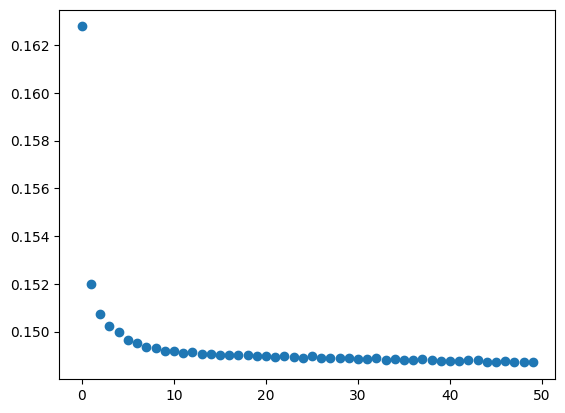

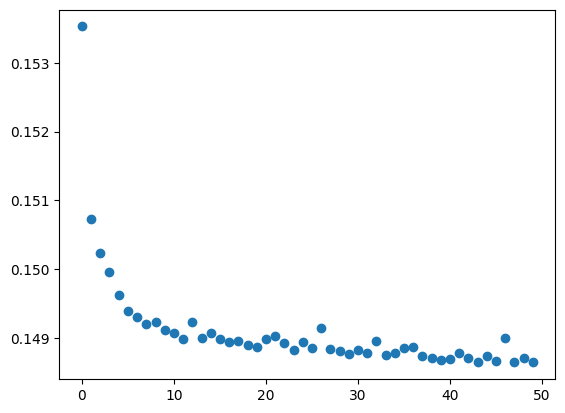

In [5]:
plt.scatter(range(len(history.history['loss'])), history.history['loss'], label='Train Loss')
plt.figure()
plt.scatter(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Loss')

In [6]:
autoencoder.save('auto_encoder.keras')

In [7]:
autoencoder = tf.keras.models.load_model('auto_encoder.keras')
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 8)         80        
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 8)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 4)         292       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 4)         0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1024)              0     

In [8]:
%run audio.ipynb

def detect_anomalies(file_path, model, threshold=0.05):
    spec = generate_fpga_style_spectrogram(file_path) # (64, 313)
    # print(f"spec shape: {spec.shape}")
    windows = spectrogram_to_tensor(spec) # 8 x 64 x 64 (nhw)
    # print(f"Windows Shape: {windows.shape}")  
    
    reconstructed = model.predict(windows)
    
    errors = np.mean(np.abs(windows - reconstructed), axis=(1, 2, 3))
    
    anomalous_indices = np.where(errors > threshold)[0]
    
    return errors, anomalous_indices

In [ ]:
# Test on new files
normal_path = '../-6_dB_slider/slider/id_02/normal/'
abnormal_path = '../-6_dB_slider/slider/id_02/abnormal/'
normal_files = [f for f in os.listdir(normal_path) if f.endswith('.wav')]
abnormal_files = [f for f in os.listdir(abnormal_path) if f.endswith('.wav')]

normal_errors = []
abnormal_errors = []

for idx, f in enumerate(normal_files):
    if idx >= 100:
        break
    errors, _ = detect_anomalies(os.path.join(normal_path, f), autoencoder)
    normal_errors.append(errors)
for idx, f in enumerate(abnormal_files):
    if idx >= 100:
        break
    errors, _ = detect_anomalies(os.path.join(abnormal_path, f), autoencoder)
    abnormal_errors.append(errors)


267
1/1 [==============================] - ETA: 0s

In [54]:
normal_errors = np.array(normal_errors)
abnormal_errors = np.array(abnormal_errors)

print(f"normal error mean: {normal_errors.mean()} std dev: {normal_errors.std()}")
print(f"normal error mean: {abnormal_errors.mean()} std dev: {abnormal_errors.std()}")

normal error mean: 0.18901900947093964 std dev: 0.024156244471669197
normal error mean: 0.14332111179828644 std dev: 0.021066924557089806
